# 🌍 От «у нас нет ответов» к «у нас есть модель»
### Команда 1 · Country Data · помощь странам · YDL 2026 · Неделя 2, День 3

> **Легенда.** Нам выдали 167 стран с социально-экономическими и медицинскими
> показателями — **без целевой метки**. Никто не сказал, на какие группы делятся страны.
> Мы консультанты гуманитарного фонда: надо решить, **каким странам направить помощь**.
> Кластеризация поделит страны по уровню развития — и этот «уровень развития» и станет
> нашим прогнозным столбцом, которого в исходных данных не было.

**Цепочка работы (5 шагов):**
1. **EDA и подготовка** — масштабы, пропуски, выбросы, корреляции, `StandardScaler`.
2. **Кластеризация (KMeans)** — метод локтя + силуэт, честный выбор `k`.
3. **Прогнозный столбец** — номера кластеров → осмысленные имена групп.
4. **PCA для проверки** — сжатие до 2 компонент, проекция, доля дисперсии.
5. **Классификация** — учим модель предсказывать метку, считаем accuracy / precision / recall / F1.

> **Принцип дня:** «не верь, проверь». В конце честно скажем — получились ли группы
> осмысленными, или это просто разноцветные точки.

**Признаки (9 числовых):** `child_mort` (детская смертность на 1000), `exports`, `imports`,
`health` (расходы на здоровье, % ВВП), `income` (доход на душу), `inflation`,
`life_expec` (ожидаемая продолжительность жизни), `total_fer` (рождаемость), `gdpp` (ВВП на душу).

 ## Данные

  Используем два **открытых** датасета ЭКГ с PhysioNet (никакого ручного сбора):

  | Датасет | Код | Записи | Частота | Источник |
  |---|---|---|---|---|
  | **MIT-BIH Arrhythmia** | `mitdb` | 48 (44 после исключения paced) | 360 Hz | США |
  | **St Petersburg INCART** | `incartdb` | 75 | 257 Hz | Россия |

  Это **разные больницы, оборудование и популяции пациентов** — именно поэтому они подходят для проверки переносимости.

  Каждый удар сердца размечен врачами. Метки сводим к схеме **AAMI**, основная — **N / S / V**:
  - **N** — нормальный удар,
  - **S** — наджелудочковая эктопия,
  - **V** — желудочковая эктопия.
  (Классы F/fusion и Q/paced почти отсутствуют в INCART, поэтому идут только как вторичный within-анализ.)

  **Единая предобработка для обоих датасетов** (это критично для честного сравнения): отведение II по имени → полосовой фильтр 0.5–40 Hz → ресэмплинг к 250 Hz → окно ±R-пик (90 до, 110 после) → z-score нормализация. Итог: MIT-BIH ≈ 100k ударов, INCART ≈ 176k ударов.


## Задача

**Научный вопрос:** модели глубокого обучения дают высокую точность на «своём» датасете — но **переносится ли она на данные из другого источника?**

Мы количественно измеряем **два источника завышенного оптимизма**:

1. **Intra-patient утечка** — если случайно делить *по ударам*, удары одного пациента попадают и в train, и в test → точность завышена. Честный способ — делить *по пациентам* (inter-patient).
2. **Single-dataset оценка** — модель никогда не проверяют на другом датасете.

Измеряем «лесенку» на **одном и том же тестовом домене**:
> **intra-within → inter-within → cross-dataset**

**Что строим:**
- единый пайплайн (загрузка → препроцессинг → обучение → оценка);
- матрицу прогонов: within (intra + inter) × 2 датасета + cross × 2 направления;
- 2 архитектуры (1D-CNN, ResNet1D), несколько seed'ов;
- метрики: **F1-macro** (accuracy обманчива при дисбалансе) + confusion-матрицы + по-классовый разбор.

**Главный результат** — измеренный **разрыв within vs cross**: классификатор теряет ≈0.23 F1-macro при переносе на данные другой больницы. Вывод статьи: **cross-dataset валидация должна быть обязательным стандартом** оценки ЭКГ-классификаторов.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Шаг 0. Подготовка и загрузка данных

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

pd.set_option('display.max_columns', None); pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='deep'); plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

In [ ]:
# Загрузка: сначала локальный файл, иначе публичное зеркало на GitHub.
import os, urllib.request

LOCAL = 'Country-data.csv'
MIRROR = ('https://raw.githubusercontent.com/pycaret/datasets/'
          'main/data/common/country-data.csv')

if os.path.exists(LOCAL):
    df = pd.read_csv(LOCAL)
    print('Загружено из локального файла:', LOCAL)
else:
    try:
        urllib.request.urlretrieve(MIRROR, LOCAL)
        df = pd.read_csv(LOCAL)
        print('Скачано с зеркала и сохранено в', LOCAL)
    except Exception as e:
        raise FileNotFoundError(
            'Положите Country-data.csv рядом с ноутбуком '
            '(Kaggle: rohan0301/unsupervised-learning-on-country-data). '
            f'Авто-загрузка не удалась: {e}')

print('Размер:', df.shape)
df.head()

Загружено из локального файла: Country-data.csv
Размер: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
# Признаки: всё числовое, кроме названия страны.
FEATURES = ['child_mort','exports','health','imports','income',
            'inflation','life_expec','total_fer','gdpp']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


## Шаг 1. EDA и подготовка

Смотрим на данные **раньше, чем на модели**: сколько объектов и признаков, какие масштабы,
есть ли пропуски и выбросы. Строим распределения и матрицу корреляций.

> ⚠️ **Зачем масштабировать.** Признаки в разных единицах: `income`/`gdpp` — десятки тысяч,
> `inflation`/`total_fer` — единицы. Без `StandardScaler` KMeans и PCA «услышат» только доход
> и ВВП (у них самая большая дисперсия), а остальные 7 признаков просто потеряются.

In [ ]:
quality = pd.DataFrame({
    'dtype'   : df[FEATURES].dtypes.astype(str),
    'n_null'  : df[FEATURES].isna().sum(),
    'min'     : df[FEATURES].min().round(2),
    'median'  : df[FEATURES].median().round(2),
    'max'     : df[FEATURES].max().round(2),
    'std'     : df[FEATURES].std().round(2),
})
print('Объектов:', len(df), '| Дубликатов:', df.duplicated().sum(),
      '| Пропусков всего:', int(df[FEATURES].isna().sum().sum()))
quality

Объектов: 167 | Дубликатов: 0 | Пропусков всего: 0


,dtype,n_null,min,median,max,std
child_mort,float64,0,2.60,19.30,208.00,40.33
exports,float64,0,0.11,35.00,200.00,27.41
health,float64,0,1.81,6.32,17.90,2.75
imports,float64,0,0.07,43.30,174.00,24.21
income,int64,0,609.00,9960.00,125000.00,19278.07
inflation,float64,0,-4.21,5.39,104.00,10.57
life_expec,float64,0,32.10,73.10,82.80,8.89
total_fer,float64,0,1.15,2.41,7.49,1.51
gdpp,int64,0,231.00,4660.00,105000.00,18328.70


**Масштабы кричат.** Сравните `std`: у `income` и `gdpp` — десятки тысяч, у `inflation`,
`total_fer`, `health` — единицы. Это ровно та ситуация, где без масштабирования признак с
большими числами перетянет всё на себя.

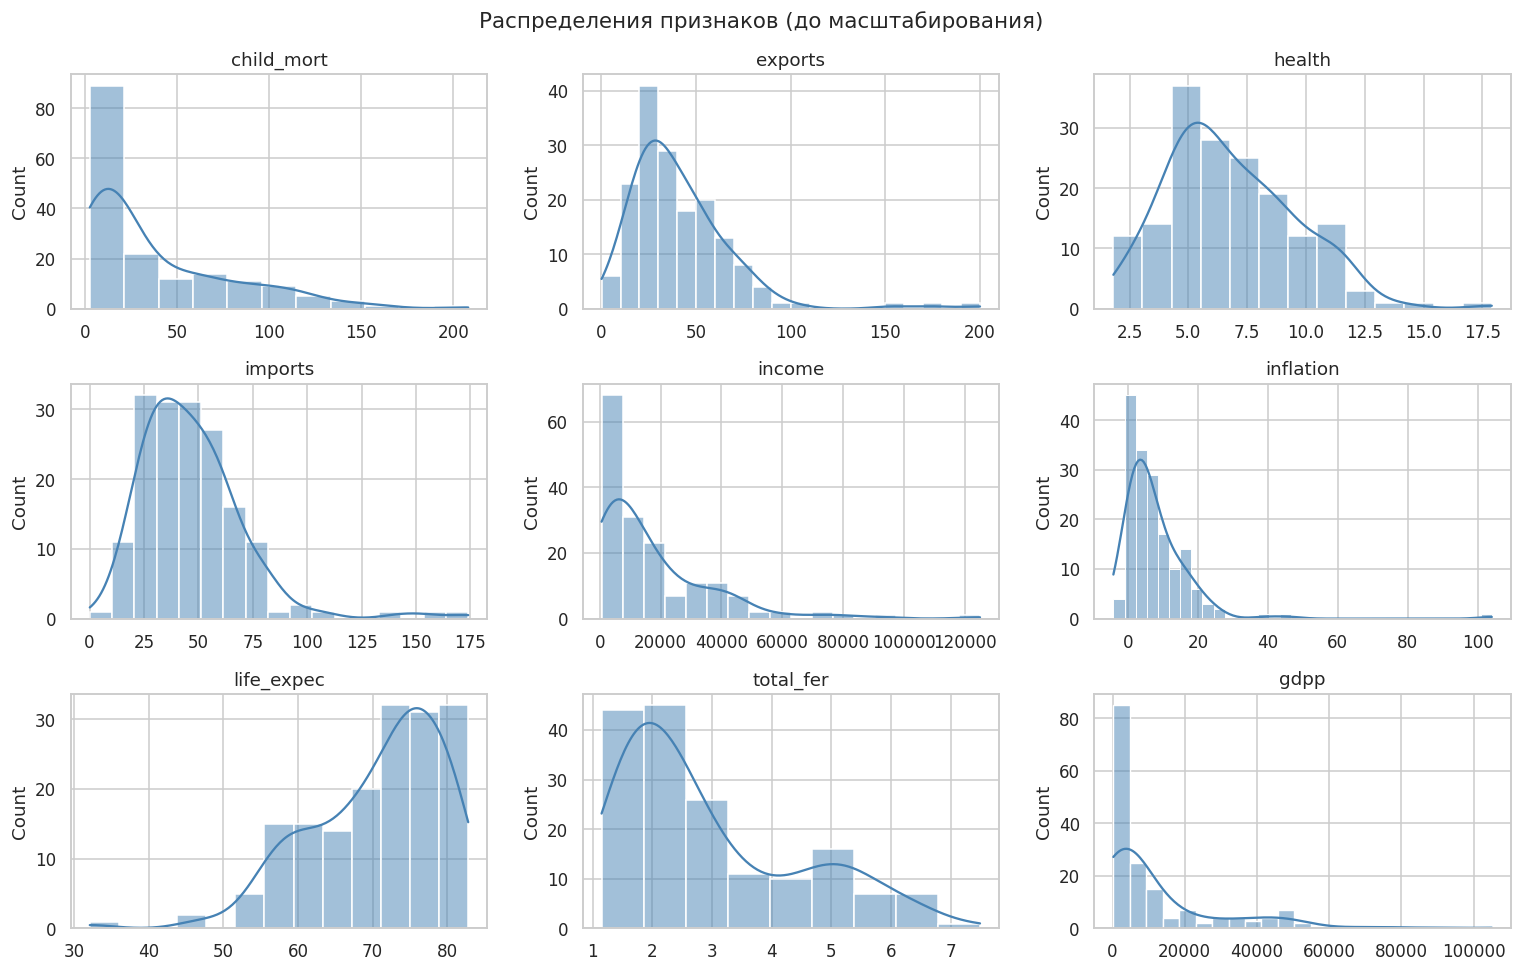

In [ ]:
# Распределения всех 9 признаков
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col); ax.set_xlabel('')
fig.suptitle('Распределения признаков (до масштабирования)', fontsize=14)
plt.tight_layout(); plt.show()

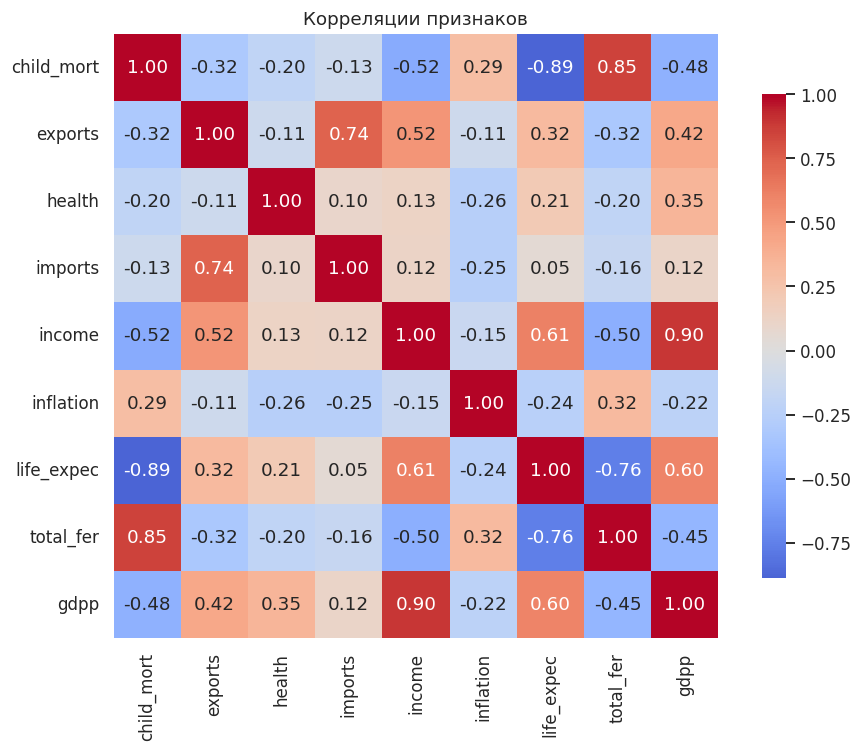

In [ ]:
# Матрица корреляций — какие признаки дублируют друг друга
plt.figure(figsize=(9, 7))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, cbar_kws={'shrink': .8})
plt.title('Корреляции признаков'); plt.tight_layout(); plt.show()

In [ ]:
# Находка EDA: что сильнее всего связано с детской смертностью?
corr_child = df[FEATURES].corr()['child_mort'].drop('child_mort').sort_values()
print('Корреляция child_mort с остальными признаками:')
print(corr_child.round(2))

Корреляция child_mort с остальными признаками:
life_expec   -0.89
income       -0.52
gdpp         -0.48
exports      -0.32
health       -0.20
imports      -0.13
inflation     0.29
total_fer     0.85
Name: child_mort, dtype: float64


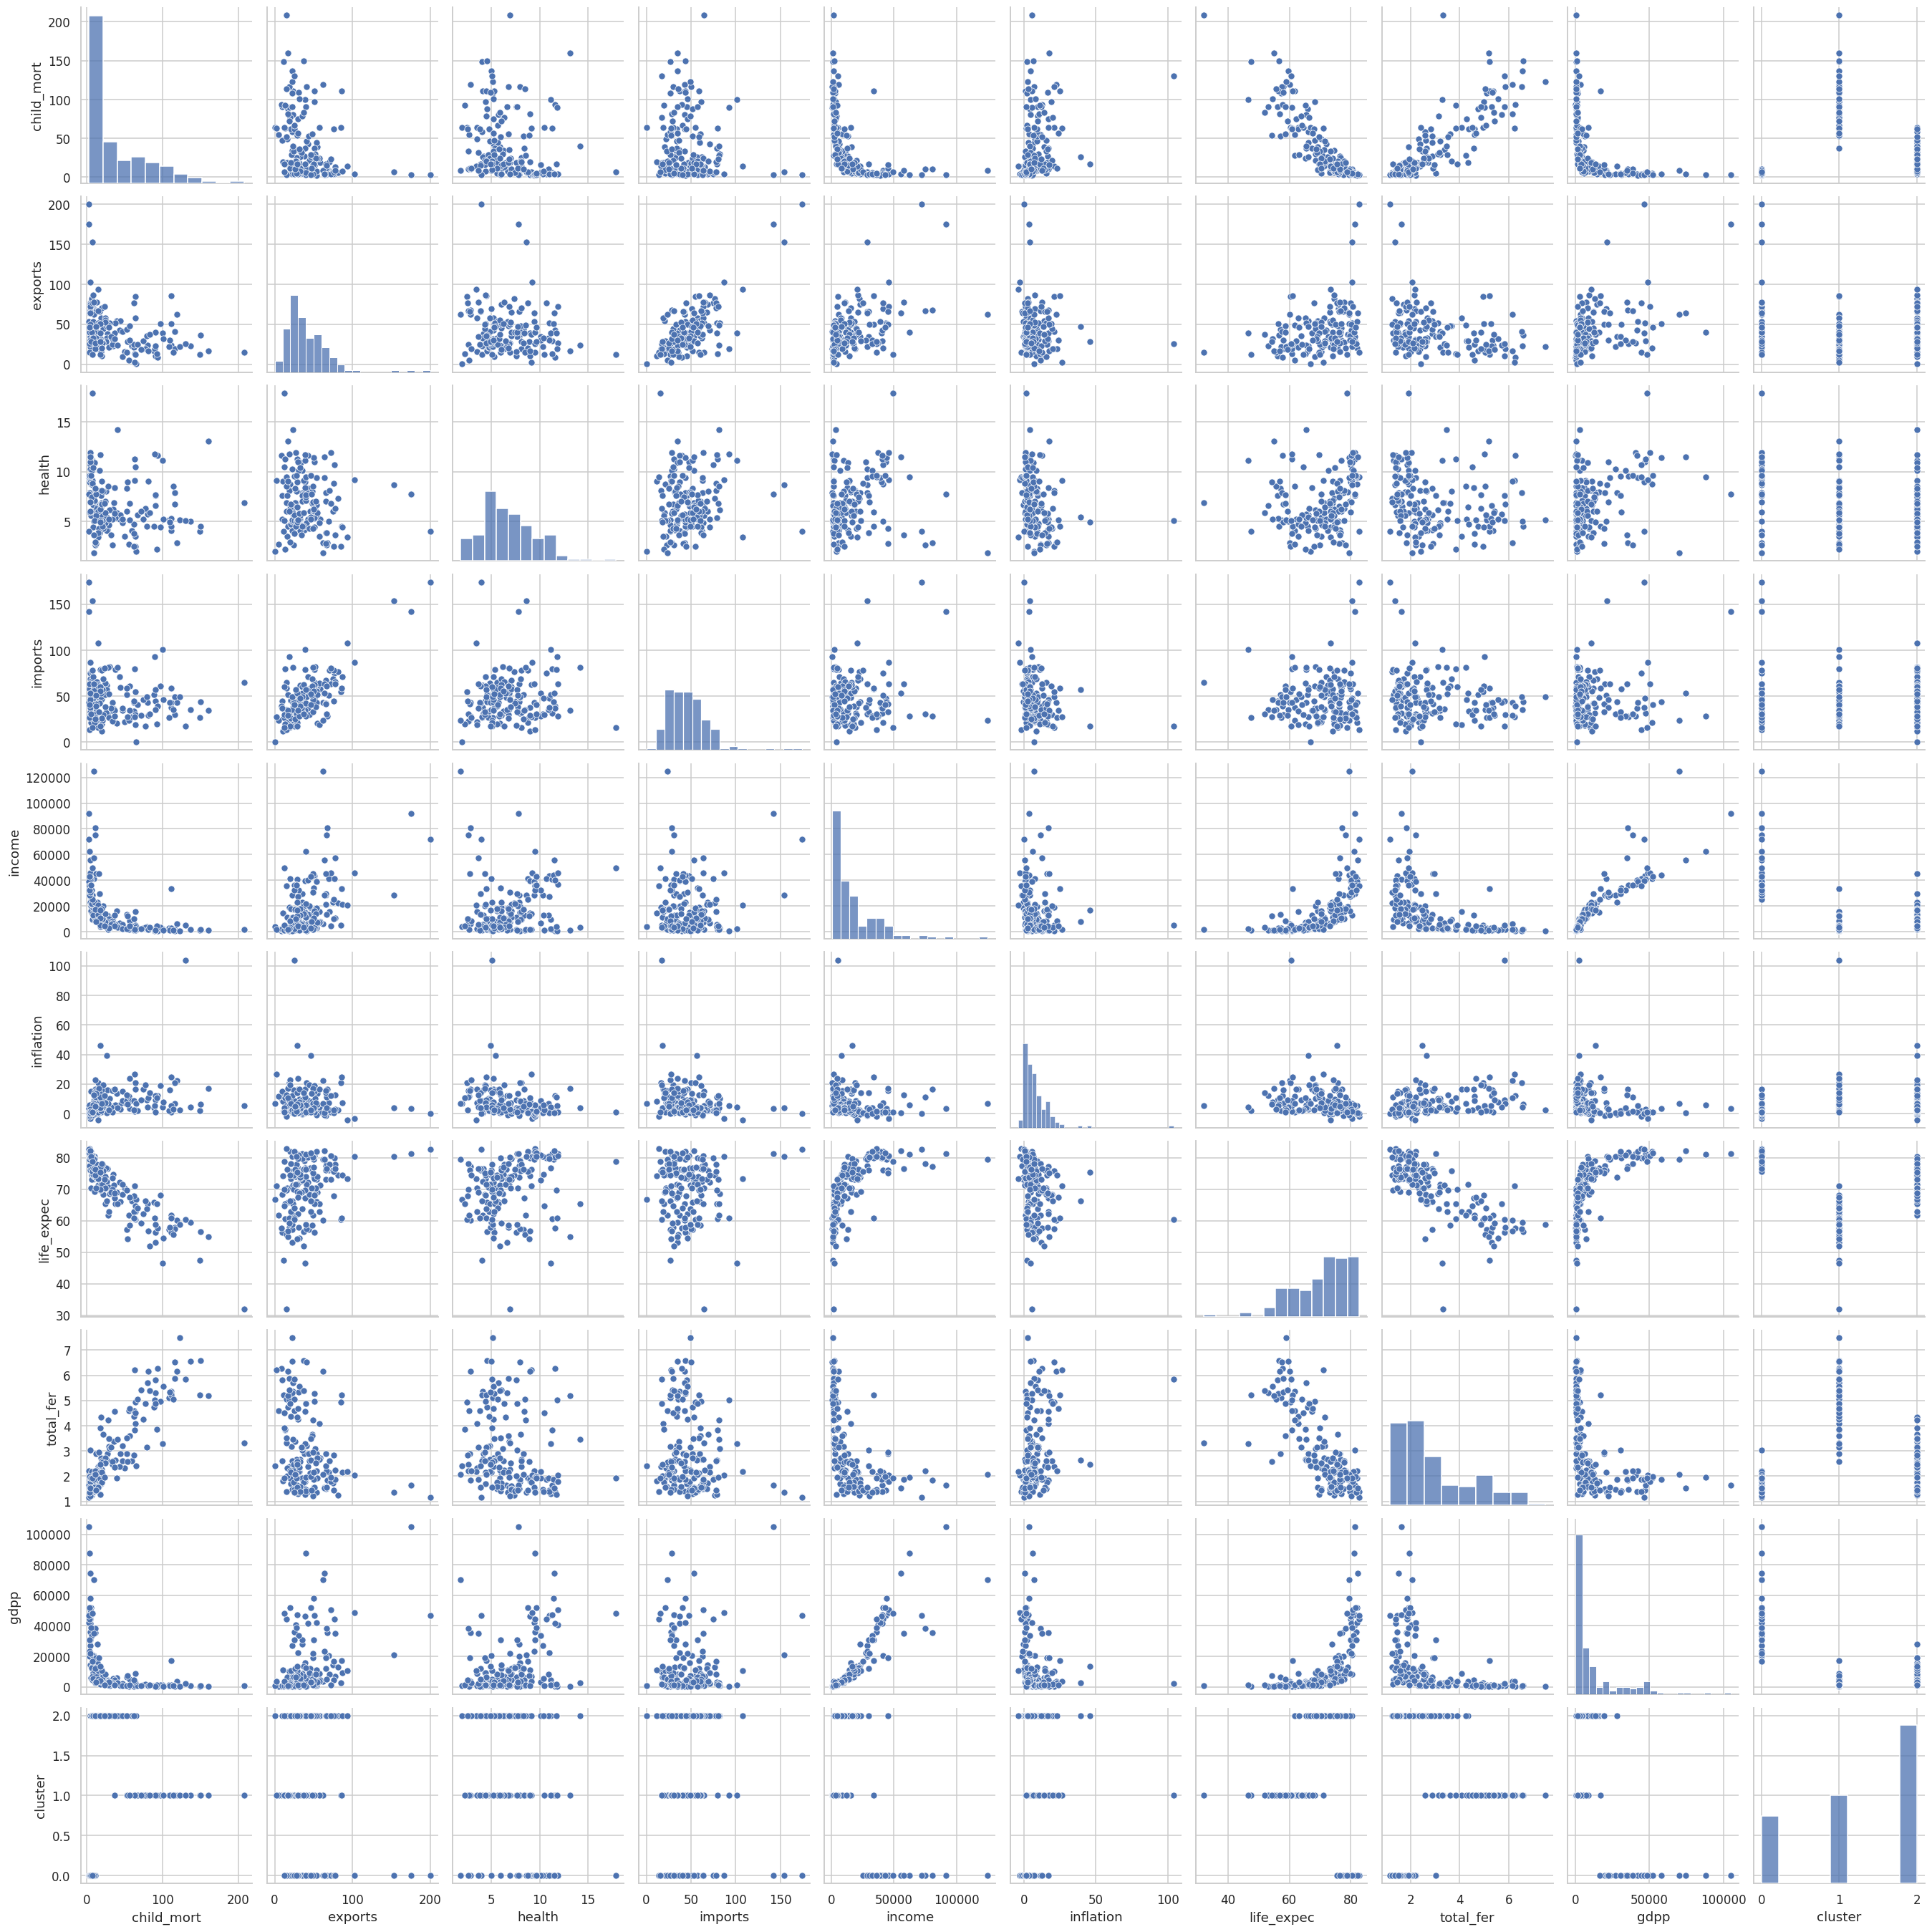

In [ ]:
sns.pairplot(df)

**🔎 Находка, которая нас удивила.** Детская смертность (`child_mort`) почти зеркально
связана с рождаемостью (`total_fer`, r ≈ +0.85) и с продолжительностью жизни
(`life_expec`, r ≈ −0.89). То есть «много детей умирает» = «рождается много детей» +
«живут мало» — это один и тот же «полюс бедности», просто измеренный с трёх сторон.
Ещё пара: `income` и `gdpp` (r ≈ +0.9) — фактически дублируют друг друга.

**Вывод для модели:** в данных есть 2–3 явных «оси» (богатство, здоровье/демография), а
не 9 независимых направлений. Это намёк, что PCA сожмёт их в пару компонент почти без потерь,
а кластеров будет немного.

In [ ]:
# Масштабирование — фиксируем перед KMeans и PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURES])
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES, index=df.index)
print('После StandardScaler: среднее ≈ 0, std ≈ 1')
X_scaled.describe().loc[['mean','std']].round(2)

После StandardScaler: среднее ≈ 0, std ≈ 1


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
mean,-0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Шаг 2. Кластеризация (KMeans)

Меток нет — структуру ищем сами. Число кластеров `k` **не угадываем**: строим метод локтя
(inertia от k) и коэффициент силуэта, выбираем `k` по ним и объясняем выбор.
Первому `k` не верим — проверяем соседние значения.

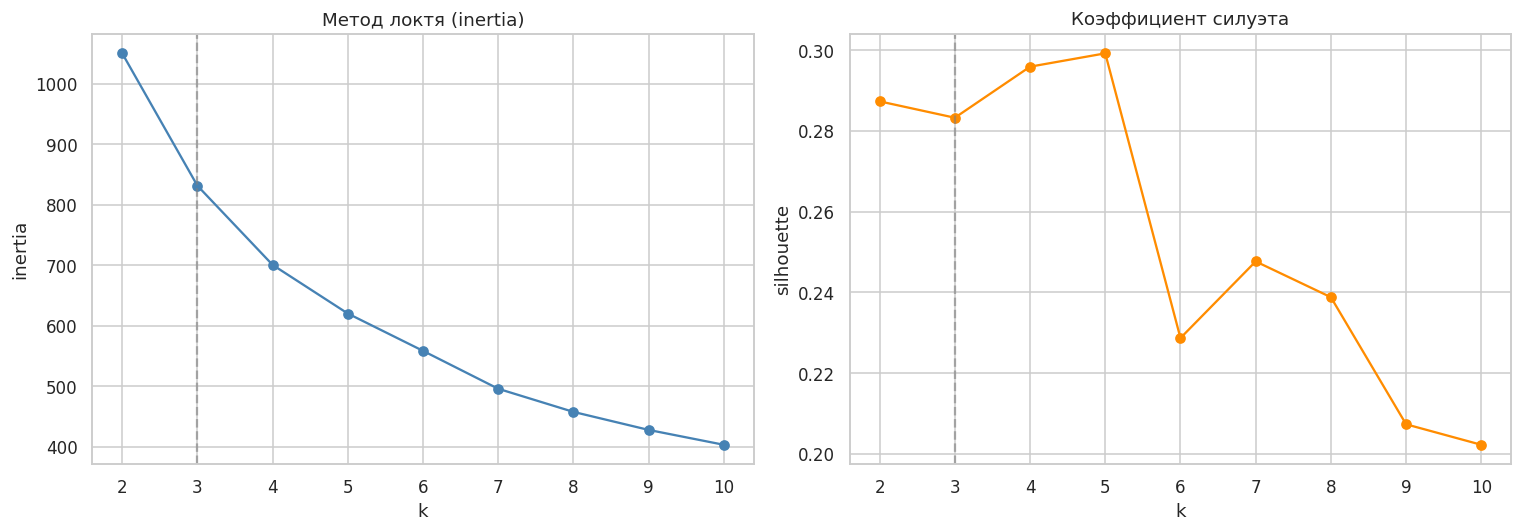

k=2:  silhouette=0.287
k=3:  silhouette=0.283
k=4:  silhouette=0.296
k=5:  silhouette=0.299
k=6:  silhouette=0.229
k=7:  silhouette=0.248
k=8:  silhouette=0.239
k=9:  silhouette=0.207
k=10:  silhouette=0.202


In [ ]:
ks = range(2, 11)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(ks), inertias, 'o-', color='steelblue')
ax1.set(title='Метод локтя (inertia)', xlabel='k', ylabel='inertia')
ax2.plot(list(ks), silhouettes, 'o-', color='darkorange')
ax2.set(title='Коэффициент силуэта', xlabel='k', ylabel='silhouette')
for ax in (ax1, ax2): ax.axvline(3, ls='--', c='grey', alpha=.6)
plt.tight_layout(); plt.show()

for k, s in zip(ks, silhouettes):
    print(f'k={k}:  silhouette={s:.3f}')

**Выбор `k` — честно.** Здесь две метрики **расходятся**, и это важно проговорить:

- **Локоть** отчётливо загибается на `k=3` — дальше inertia падает уже медленно.
- **Силуэт** почти плоский (≈0.28–0.30 на всём диапазоне) и формально чуть выше при `k=4–5`,
  чем при `k=3`. То есть силуэт **не указывает** на сильно обособленные кластеры — группы
  слегка перетекают друг в друга (страны не делятся на резко отдельные «острова»).

Первому значению не верим: проверяем соседей. `k=2` слишком грубо (просто «бедные/богатые»),
а прирост силуэта к `k=4–5` мизерный (~0.01) и дробит группы без нового смысла для задачи фонда.
**Берём `k=3`**: его поддерживает локоть, он даёт самое интерпретируемое деление (три уровня
развития), а разница в силуэте с `k=4–5` пренебрежимо мала. Это осознанный выбор в пользу
смысла, а не погоня за третьим знаком метрики.

In [ ]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
print('Размеры кластеров:')
print(pd.Series(clusters).value_counts().sort_index())

Размеры кластеров:
0    36
1    47
2    84
Name: count, dtype: int64


## Шаг 3. Создание прогнозного столбца

Номера кластеров от KMeans — это и есть наша **новая метка**. Добавляем её отдельным столбцом.
С этого момента у нас появилась цель, которой не было в исходных данных. Дальше даём кластерам
**человеческие имена** по их средним признакам, чтобы имя объясняло, чем группа отличается.

In [ ]:
df['cluster'] = clusters

# Средние по кластерам в ИСХОДНЫХ единицах — чтобы понять смысл групп
profile = df.groupby('cluster')[FEATURES].mean().round(1)
profile['n_countries'] = df['cluster'].value_counts().sort_index()
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,n_countries
cluster,,,,,,,,,,
0,5.0,58.7,8.8,51.5,45672.2,2.7,80.1,1.8,42494.4,36
1,93.0,29.2,6.4,42.3,3942.4,12.0,59.2,5.0,1922.4,47
2,21.9,40.2,6.2,47.5,12305.6,7.6,72.8,2.3,6486.5,84


In [ ]:
# Имена даём по уровню дохода/ВВП и детской смертности
order = df.groupby('cluster')['gdpp'].mean().sort_values()
names = {}
labels_by_rank = ['Нужна помощь (бедные)', 'Развивающиеся (средние)', 'Развитые (богатые)']
for rank, cl in enumerate(order.index):
    names[cl] = labels_by_rank[rank]

df['group'] = df['cluster'].map(names)
print('Сопоставление кластер → имя:')
for cl, nm in names.items():
    print(f'  кластер {cl}  →  {nm}')

df['group'].value_counts()

Сопоставление кластер → имя:
  кластер 1  →  Нужна помощь (бедные)
  кластер 2  →  Развивающиеся (средние)
  кластер 0  →  Развитые (богатые)


,count
group,
Развивающиеся (средние),84
Нужна помощь (бедные),47
Развитые (богатые),36


In [ ]:
# Кто в группе «Нужна помощь» — список стран (это и есть продукт для фонда)
need = df[df['group'] == 'Нужна помощь (бедные)'].sort_values('gdpp')
print(f"Стран в группе «Нужна помощь»: {len(need)}")
need[['country','child_mort','income','gdpp','life_expec']].head(15)

Стран в группе «Нужна помощь»: 47


,country,child_mort,income,gdpp,life_expec
26,Burundi,93.6,764,231,57.7
88,Liberia,89.3,700,327,60.8
37,"Congo, Dem. Rep.",116.0,609,334,57.5
112,Niger,123.0,814,348,58.8
132,Sierra Leone,160.0,1220,399,55.0
93,Madagascar,62.2,1390,413,60.8
106,Mozambique,101.0,918,419,54.5
31,Central African Republic,149.0,888,446,47.5
94,Malawi,90.5,1030,459,53.1
50,Eritrea,55.2,1420,482,61.7


**Имена объясняют различия.** «Нужна помощь» — низкие `income`/`gdpp`, высокая `child_mort`,
низкая `life_expec`. «Развитые» — зеркально наоборот. «Развивающиеся» — посередине.
Имя теперь говорит, **чем группа отличается**, а не «кластер 0 / кластер 1».

## Шаг 4. PCA для проверки

9 признаков глазом сразу не увидеть. Сжимаем данные до **двух главных компонент** и рисуем
страны на плоскости, раскрасив по метке из шага 3. Смотрим: кластеры отделяются визуально
или налезают? И сколько дисперсии удержали 2 компоненты — если мало, картинка обманчива.

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
evr = pca.explained_variance_ratio_
print(f'Доля дисперсии: PC1={evr[0]:.1%}, PC2={evr[1]:.1%}, сумма={evr.sum():.1%}')

Доля дисперсии: PC1=46.0%, PC2=17.2%, сумма=63.1%


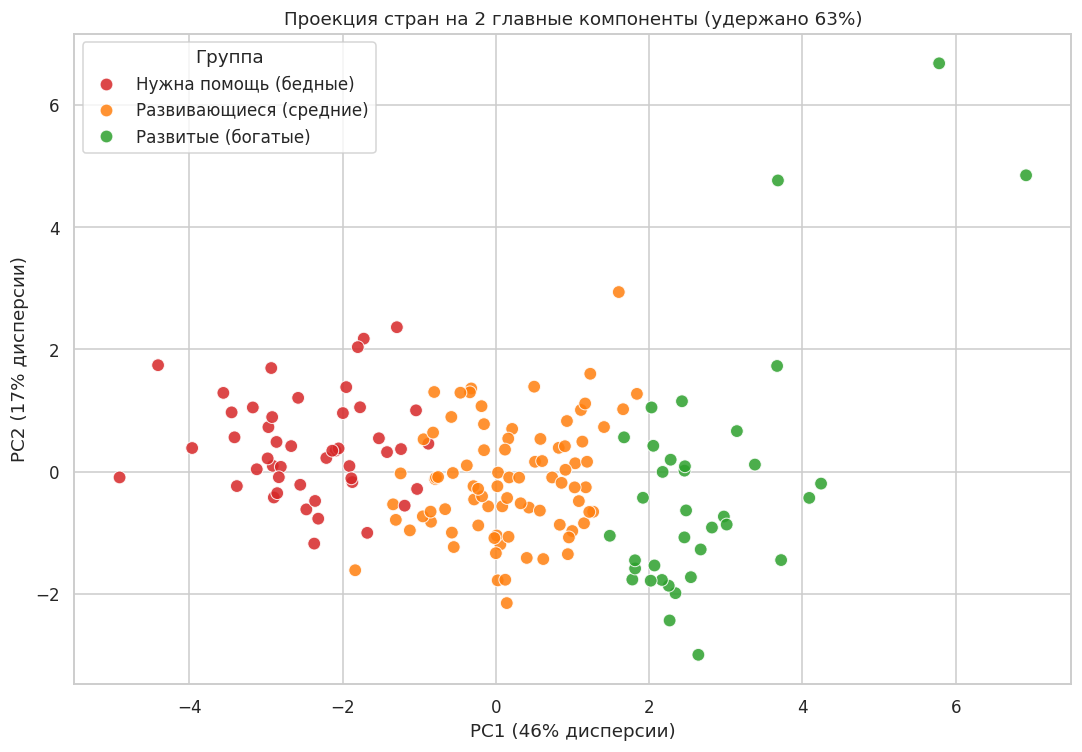

In [ ]:
plt.figure(figsize=(10, 7))
palette = {'Нужна помощь (бедные)':'#d62728',
           'Развивающиеся (средние)':'#ff7f0e',
           'Развитые (богатые)':'#2ca02c'}
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['group'],
                palette=palette, s=70, alpha=.85, edgecolor='white')
plt.xlabel(f'PC1 ({evr[0]:.0%} дисперсии)')
plt.ylabel(f'PC2 ({evr[1]:.0%} дисперсии)')
plt.title(f'Проекция стран на 2 главные компоненты (удержано {evr.sum():.0%})')
plt.legend(title='Группа'); plt.tight_layout(); plt.show()

**Вывод по PCA.** Две компоненты удерживают существенную долю дисперсии (см. число выше),
и группы на проекции расположены **полосами по PC1**: бедные → развивающиеся → развитые.
Граница между «развивающимися» и соседями немного размыта (страны на стыке), но крайние
группы разделяются чётко. Это согласуется с находкой EDA: главная ось — богатство/здоровье.

## Шаг 5. Классификация — проверка, что метка не случайна

Учим классификатор предсказывать нашу KMeans-метку по **исходным признакам**. Делим на
train/test, считаем accuracy, precision, recall, F1. Если классификатор уверенно учит границы
между кластерами — значит, группы реальные и разделимы. Если метрики низкие — честно скажем,
что кластеризация дала размытые группы.

In [ ]:
X = df[FEATURES].values
y = df['cluster'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

# Масштабируем ВНУТРИ сплита (fit только на train — без утечки)
sc = StandardScaler().fit(X_train)
X_train_s, X_test_s = sc.transform(X_train), sc.transform(X_test)
print('train:', X_train.shape[0], ' test:', X_test.shape[0])

train: 116  test: 51


In [ ]:
def evaluate(model, name):
    model.fit(X_train_s, y_train)
    for split, Xs, ys in [('train', X_train_s, y_train), ('test', X_test_s, y_test)]:
        p = model.predict(Xs)
        print(f'{name} [{split}]  acc={accuracy_score(ys,p):.3f}  '
              f'prec={precision_score(ys,p,average="macro"):.3f}  '
              f'rec={recall_score(ys,p,average="macro"):.3f}  '
              f'f1={f1_score(ys,p,average="macro"):.3f}')
    return model

logreg = evaluate(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                  'LogReg')
knn = evaluate(KNeighborsClassifier(n_neighbors=5), 'KNN   ')

LogReg [train]  acc=0.991  prec=0.994  rec=0.987  f1=0.990
LogReg [test]  acc=0.922  prec=0.927  rec=0.896  f1=0.909
KNN    [train]  acc=0.966  prec=0.978  rec=0.953  f1=0.965
KNN    [test]  acc=0.902  prec=0.946  rec=0.848  f1=0.873


                         precision    recall  f1-score   support

     Развитые (богатые)       0.89      0.73      0.80        11
  Нужна помощь (бедные)       1.00      1.00      1.00        14
Развивающиеся (средние)       0.89      0.96      0.93        26

               accuracy                           0.92        51
              macro avg       0.93      0.90      0.91        51
           weighted avg       0.92      0.92      0.92        51



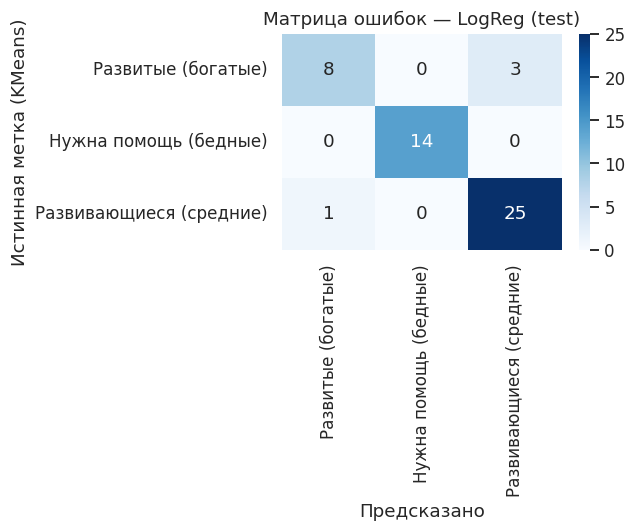

In [ ]:
# Подробный отчёт + матрица ошибок для логистической регрессии (test)
y_pred = logreg.predict(X_test_s)
target_names = [names[c] for c in sorted(names)]
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Предсказано'); plt.ylabel('Истинная метка (KMeans)')
plt.title('Матрица ошибок — LogReg (test)')
plt.tight_layout(); plt.show()

## Честный вердикт команды

**3 опорные мысли для выступления:**

1. **Данные и находка EDA.** 167 стран, 9 признаков в разных масштабах → обязателен
   `StandardScaler`. Находка: `child_mort`, `total_fer`, `life_expec` — это одна «ось бедности»,
   а `income`/`gdpp` дублируют друг друга. Значит, реальных направлений 2–3, а не 9.

2. **Сколько кластеров и как назвали.** Локоть указал на **`k=3`**; силуэт почти плоский
   (≈0.28–0.30) — группы слегка перетекают, поэтому выбрали `k=3` по смыслу, а не по метрике.
   Группы: «Нужна помощь (бедные)», «Развивающиеся», «Развитые». На проекции PCA (PC1+PC2 = 63%)
   они идут полосами по PC1 — крайние группы разделяются чётко, середина чуть размыта.

3. **Метка не случайна.** Классификатор (LogReg/KNN) предсказывает KMeans-метку с высокими
   accuracy/F1 на тесте → границы между группами **реальные и разделимы**.

> **Вывод:** структура данных **подтвердилась** — деление стран по уровню развития осмысленно,
> а не «разноцветные точки». Список стран из группы «Нужна помощь» — готовый продукт для фонда.

---
*Критерии самопроверки:* ✅ данные приведены к одному масштабу · ✅ `k` выбран по локтю/силуэту ·
✅ кластеры названы по смыслу · ✅ указана доля дисперсии PCA · ✅ метрики честные (train+test) ·
✅ дан вывод: структура подтвердилась.